<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB
None
condition
0    160
1    137
Name: count, dtype: int64


<Axes: xlabel='condition', ylabel='count'>

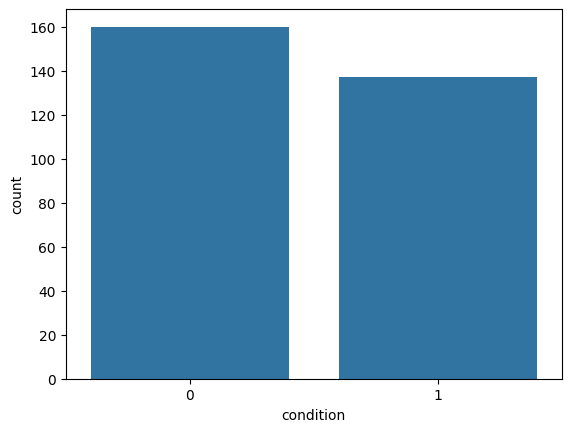

In [2]:
import pandas as pd
import seaborn as sns

df = pd.read_csv('heart_cleveland_upload.csv')
print(df.info())
print(df['condition'].value_counts())
sns.countplot(x='condition', data=df)

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop('condition', axis=1)
y = df['condition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

models = {
  "SVM": SVC(probability=True),
  "Naive Bayes": GaussianNB(),
  "Random Forest": RandomForestClassifier(random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
  scores = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring='f1')
  print(f"{name}: F1 = {scores.mean():.4f} ± {scores.std():.4f}")

SVM: F1 = 0.7969 ± 0.0540
Naive Bayes: F1 = 0.8105 ± 0.0295
Random Forest: F1 = 0.8358 ± 0.0456



SVM
              precision    recall  f1-score   support

           0       0.84      1.00      0.91        32
           1       1.00      0.79      0.88        28

    accuracy                           0.90        60
   macro avg       0.92      0.89      0.90        60
weighted avg       0.92      0.90      0.90        60


Naive Bayes
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        32
           1       1.00      0.71      0.83        28

    accuracy                           0.87        60
   macro avg       0.90      0.86      0.86        60
weighted avg       0.89      0.87      0.86        60


Random Forest
              precision    recall  f1-score   support

           0       0.83      0.94      0.88        32
           1       0.92      0.79      0.85        28

    accuracy                           0.87        60
   macro avg       0.88      0.86      0.86        60
weighted avg       0.87      0.87      0.

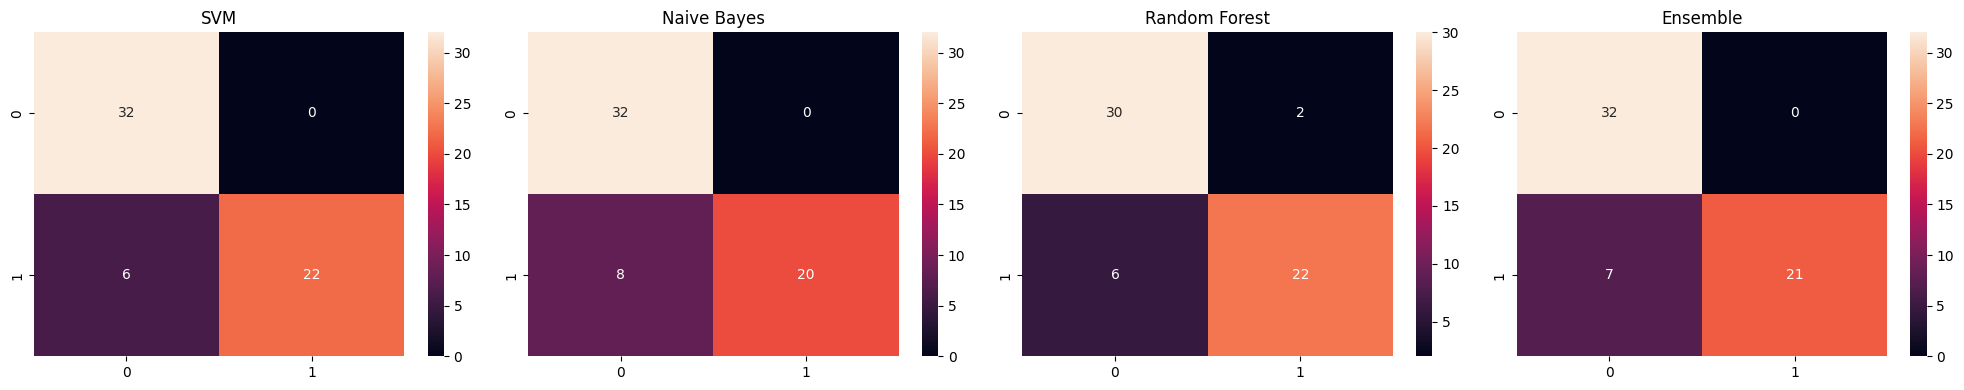

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

for name, model in models.items():
  model.fit(X_train_res, y_train_res)

for name, model in models.items():
  preds = model.predict(X_test_scaled)
  print(f"\n{name}")
  print(classification_report(y_test, preds))

from scipy.stats import mode

svm_preds = models["SVM"].predict(X_test_scaled)
nb_preds = models["Naive Bayes"].predict(X_test_scaled)
rf_preds = models["Random Forest"].predict(X_test_scaled)

ensemble_preds = mode(
  [svm_preds, nb_preds, rf_preds], axis=0
).mode.flatten()

print("\nEnsemble:")
print(classification_report(y_test, ensemble_preds))

fig, axes = plt.subplots(1, 4, figsize=(20,4))
for ax, (name, model) in zip(axes[:3], models.items()):
  cm = confusion_matrix(y_test, model.predict(X_test_scaled))
  sns.heatmap(cm, annot=True, fmt='d', ax=ax)
  ax.set_title(name)

cm_ens = confusion_matrix(y_test, ensemble_preds)
sns.heatmap(cm_ens, annot=True, fmt='d', ax=axes[3])
axes[3].set_title("Ensemble")
plt.tight_layout()


Text(0.5, 1.0, 'Feature Importance - Random Forest')

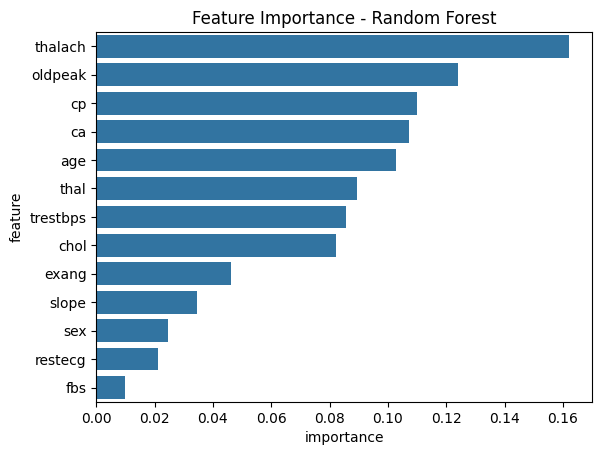

In [7]:
importances = models["Random Forest"].feature_importances_
feat_df = pd.DataFrame({'feature': X.columns, 'importance':importances})
feat_df = feat_df.sort_values('importance', ascending=False)
sns.barplot(x='importance', y='feature', data=feat_df)
plt.title("Feature Importance - Random Forest")